# Scverse Owkin Hackathon: 3D Point Cloud Viz of Thick MERFISH
Data obtained from https://elifesciences.org/reviewed-preprints/90029v1

In [2]:
%load_ext autoreload
%autoreload 2
%env ANYWIDGET_HMR=1

env: ANYWIDGET_HMR=1


In [3]:
import anndata as ad

import pandas as pd
import scanpy as sc
import squidpy as sq

import celldega as dega
from ipywidgets import Widget

from http.server import HTTPServer, SimpleHTTPRequestHandler
import pandas as pd
import threading as thr
import requests as rq
from copy import deepcopy

/Users/feni/Documents/celldega/dega/lib/python3.12/site-packages/h5py/__init__.py:36: UserWarning: h5py is running against HDF5 1.14.5 when it was built against 1.14.6, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "
/Users/feni/Documents/celldega/dega/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/feni/Documents/celldega/dega/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources im

In [3]:
import matplotlib.pyplot as plt
from matplotlib.colors import to_hex

In [5]:
class CORSHTTPRequestHandler(SimpleHTTPRequestHandler):
    def end_headers(self):
        self.send_header('Access-Control-Allow-Origin', '*')
        self.send_header('Access-Control-Allow-Methods', 'GET, OPTIONS')
        self.send_header('Access-Control-Allow-Headers', 'X-Requested-With, content-type, Authorization')  # Added Authorization
        self.send_header('Access-Control-Allow-Credentials', 'true')
        super().end_headers()

    def do_OPTIONS(self):
        self.send_response(200)
        self.end_headers()

    def log_message(self, format, *args):
        # Override log_message to prevent logging to the console.
        pass


server = HTTPServer(("", 0), CORSHTTPRequestHandler)
print(f"Server running on port {server.server_address[1]}")

service = thr.Thread(target=server.serve_forever)
service.start()

server_address = server.server_address[1]
server_address

Server running on port 62640


62640

# Read AnnData Zarr

In [4]:
adata = ad.read_zarr('data/hackathon/thick_merfish/tables/expression/')

In [5]:
adata

AnnData object with n_obs × n_vars = 76356 × 252
    obs: 'fov', 'num_z', 'area', 'x', 'y', 'center_z', 'center_x', 'center_y', 'min_x', 'max_x', 'min_y', 'max_y', 'voxel_x', 'voxel_y', 'voxel_z'

In [111]:
adata.obs.head()

,fov,num_z,area,x,y,center_z,center_x,center_y,min_x,max_x,min_y,max_y,voxel_x,voxel_y,voxel_z,leiden
id,,,,,,,,,,,,,,,,
00183a9dcb67459aa64290aca87bfdfb,0,21,2747.626362,208.5,295.5,12.0,932.646139,259.522873,923.198389,942.093889,252.853873,266.191873,740,55,4,0
005e01b8e6b54b8f9e0fea3d526a3743,0,14,765.229588,331.0,594.5,28.5,950.561763,303.251622,944.112139,957.011388,298.776372,307.726871,763,110,10,5
006f5fbed3fb43e5ad829884ddd765b1,0,2,11.593727,1818.5,96.5,4.5,1168.108630,230.419124,1166.119630,1170.097630,228.722624,232.115624,1035,19,1,8
00a616b091f74d32892b2a8a9c71eb13,0,4,171.563369,1714.0,1418.5,98.5,1152.825506,423.761617,1147.107131,1158.543881,418.847617,428.675617,1016,260,38,16
010eb518f8b445de9a807f1fea9f60ae,0,10,1088.142808,921.0,904.0,95.5,1036.849260,348.515995,1027.620886,1046.077635,342.358870,354.673120,871,166,37,0


In [11]:
meta_cell = pd.DataFrame(index=adata.obs.index.tolist())

In [47]:
meta_cell['geometry'] = adata.obs.apply(lambda row: [
    row["center_x"], 
    row["center_y"], 
    row["center_z"]], axis=1)

meta_cell['name'] = pd.Series(meta_cell.index.tolist(), index=meta_cell.index.tolist())
meta_cell['batch'] = pd.Series(0, index=meta_cell.index.tolist())

In [48]:
meta_cell.head()

,geometry,name,batch
00183a9dcb67459aa64290aca87bfdfb,"[932.6461390182376, 259.52287317067385, 12.0]",00183a9dcb67459aa64290aca87bfdfb,0
005e01b8e6b54b8f9e0fea3d526a3743,"[950.5617633610964, 303.25162156671286, 28.5]",005e01b8e6b54b8f9e0fea3d526a3743,0
006f5fbed3fb43e5ad829884ddd765b1,"[1168.1086303815246, 230.41912423819304, 4.5]",006f5fbed3fb43e5ad829884ddd765b1,0
00a616b091f74d32892b2a8a9c71eb13,"[1152.8255059421062, 423.7616171464324, 98.5]",00a616b091f74d32892b2a8a9c71eb13,0
010eb518f8b445de9a807f1fea9f60ae,"[1036.8492601960895, 348.5159949064255, 95.5]",010eb518f8b445de9a807f1fea9f60ae,0


In [49]:
cluster = pd.DataFrame(index=meta_cell.index.tolist())
cluster['cluster'] = pd.Series(0, index=meta_cell.index.tolist())

In [50]:
cluster.head()

,cluster
00183a9dcb67459aa64290aca87bfdfb,0
005e01b8e6b54b8f9e0fea3d526a3743,0
006f5fbed3fb43e5ad829884ddd765b1,0
00a616b091f74d32892b2a8a9c71eb13,0
010eb518f8b445de9a807f1fea9f60ae,0


In [20]:
!mkdir data/hackathon/thick_merfish/landscape_files
!mkdir data/hackathon/thick_merfish/landscape_files/cell_clusters

In [21]:
meta_cluster = pd.DataFrame()
meta_cluster.loc[0, 'count'] = 100
meta_cluster.loc[0, 'color'] = '#023fa5'

### Save Parquets for LandscapeFiles

In [51]:
meta_cell.to_parquet('data/hackathon/thick_merfish/landscape_files/cell_metadata.parquet')

In [31]:
cbg = adata.to_df()

In [34]:
cbg.head()

,1700022I11Rik,1810046K07Rik,5031425F14Rik,5730522E02Rik,Acta2,Adam2,Adamts2,Adamts4,Adra1b,Alk,...,Blank-1,Blank-2,Blank-3,Blank-4,Blank-5,Blank-6,Blank-7,Blank-8,Blank-9,Blank-10
id,,,,,,,,,,,,,,,,,,,,,
00183a9dcb67459aa64290aca87bfdfb,0.0,0.0,0.0,2.0,2.0,0.0,0.0,0.0,2.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0
005e01b8e6b54b8f9e0fea3d526a3743,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
006f5fbed3fb43e5ad829884ddd765b1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
00a616b091f74d32892b2a8a9c71eb13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
010eb518f8b445de9a807f1fea9f60ae,0.0,0.0,0.0,1.0,1.0,1.0,0.0,2.0,6.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0


In [38]:
meta_gene = dega.pre.calc_meta_gene_data(cbg)

cbg is a dense DataFrame. Proceeding with dense operations.
Calculating mean expression
Calculating variance


In [44]:
meta_gene.head()

,mean,std,max,non-zero
1700022I11Rik,0.141705,7.476619,7.0,0.116978
1810046K07Rik,0.166955,8.290284,6.0,0.131922
5031425F14Rik,0.134200,7.742341,8.0,0.106200
5730522E02Rik,0.139177,7.308390,5.0,0.115616
Acta2,1.057795,85.096349,213.0,0.377678


In [56]:
genes = meta_gene.index.tolist()

In [58]:
# Get all categorical color palettes from Matplotlib and flatten them into a single list of colors
palettes = [plt.get_cmap(name).colors for name in plt.colormaps() if "tab" in name]
flat_colors = [color for palette in palettes for color in palette]

# Convert RGB tuples to hex codes
flat_colors_hex = [to_hex(color) for color in flat_colors]

# Use modular arithmetic to assign a color to each gene, white for genes with "Blank"
colors = [
    flat_colors_hex[i % len(flat_colors_hex)] if "Blank" not in gene else "#FFFFFF"
    for i, gene in enumerate(genes)
]

# Create a DataFrame with genes and their assigned colors
ser_color = pd.Series(colors, index=genes)

# calculate gene expression metadata
# meta_gene = calc_meta_gene_data(cbg)
meta_gene['color'] = ser_color

In [59]:
meta_gene.head()

,mean,std,max,non-zero,color
1700022I11Rik,0.141705,7.476619,7.0,0.116978,#1f77b4
1810046K07Rik,0.166955,8.290284,6.0,0.131922,#ff7f0e
5031425F14Rik,0.134200,7.742341,8.0,0.106200,#2ca02c
5730522E02Rik,0.139177,7.308390,5.0,0.115616,#d62728
Acta2,1.057795,85.096349,213.0,0.377678,#9467bd


In [60]:
meta_gene.to_parquet('data/hackathon/thick_merfish/landscape_files/meta_gene.parquet')

## CBG

In [64]:
path_landscape_files = 'data/hackathon/thick_merfish/landscape_files'

In [66]:
dega.pre.save_cbg_gene_parquets(path_landscape_files, cbg, verbose=True)

Processing gene 0: 1700022I11Rik
Processing gene 100: Igfbp4
Processing gene 200: Slc32a1


## Cluster

In [68]:
# Saving count data
adata.layers["counts"] = adata.X.copy()

In [69]:
# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)

/Users/feni/anaconda3/envs/celldega_3.9/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))


In [70]:
sc.tl.pca(adata)

In [72]:
# sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

In [73]:
sc.pp.neighbors(adata)

/Users/feni/anaconda3/envs/celldega_3.9/lib/python3.9/site-packages/scipy/sparse/_index.py:145: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


In [74]:
sc.tl.umap(adata)

In [78]:
# Using the igraph implementation and a fixed number of iterations can be significantly faster, especially for larger datasets
sc.tl.leiden(adata, flavor="igraph", n_iterations=2)

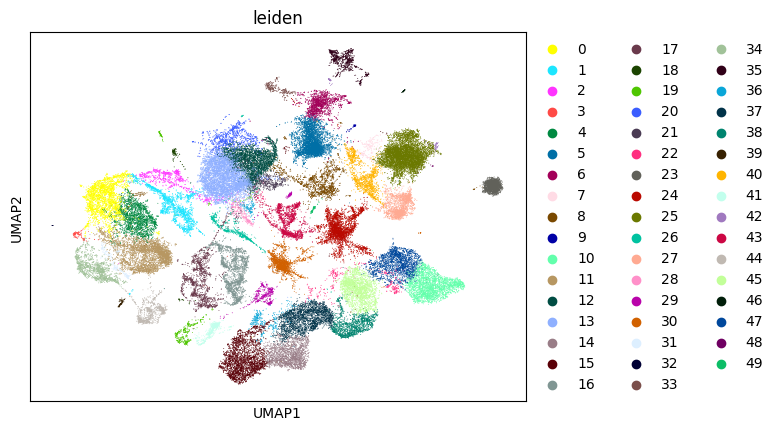

In [79]:
sc.pl.umap(adata, color=["leiden"])

In [80]:
adata.obs.head()

,fov,num_z,area,x,y,center_z,center_x,center_y,min_x,max_x,min_y,max_y,voxel_x,voxel_y,voxel_z,leiden
id,,,,,,,,,,,,,,,,
00183a9dcb67459aa64290aca87bfdfb,0,21,2747.626362,208.5,295.5,12.0,932.646139,259.522873,923.198389,942.093889,252.853873,266.191873,740,55,4,0
005e01b8e6b54b8f9e0fea3d526a3743,0,14,765.229588,331.0,594.5,28.5,950.561763,303.251622,944.112139,957.011388,298.776372,307.726871,763,110,10,5
006f5fbed3fb43e5ad829884ddd765b1,0,2,11.593727,1818.5,96.5,4.5,1168.108630,230.419124,1166.119630,1170.097630,228.722624,232.115624,1035,19,1,8
00a616b091f74d32892b2a8a9c71eb13,0,4,171.563369,1714.0,1418.5,98.5,1152.825506,423.761617,1147.107131,1158.543881,418.847617,428.675617,1016,260,38,16
010eb518f8b445de9a807f1fea9f60ae,0,10,1088.142808,921.0,904.0,95.5,1036.849260,348.515995,1027.620886,1046.077635,342.358870,354.673120,871,166,37,0


In [86]:
list_ser = []
for inst_cat in adata.obs['leiden'].unique().tolist():
    if inst_cat is not None:
        inst_cells = adata.obs[adata.obs['leiden'] == inst_cat].index.tolist()
        # print(inst_cat, len(inst_cells))

        inst_ser = cbg.loc[inst_cells].sum()/len(inst_cells)
        inst_ser.name = inst_cat

        list_ser.append(inst_ser)

df_sig = pd.concat(list_ser, axis=1)

df_sig = pd.concat(list_ser, axis=1)
df_sig.columns = df_sig.columns.tolist()
df_sig.index = df_sig.index.tolist()

keep_genes = df_sig.index.tolist()
keep_genes = [x for x in keep_genes if 'Blank' not in x]
keep_genes = [x for x in keep_genes if 'Unassigned' not in x]
keep_genes = [x for x in keep_genes if 'NegControl' not in x]
keep_genes = [x for x in keep_genes if 'DeprecatedCodeword' not in x]
len(keep_genes)

df_sig = df_sig.loc[keep_genes]

# df_sig.sparse.to_dense().to_parquet(path_landscape_files + 'df_sig.parquet')

In [108]:
df_sig.head()

,0,5,8,16,19,13,23,24,1,20,...,37,38,46,45,22,47,48,10,32,49
1700022I11Rik,0.065128,0.025202,0.002153,0.059580,0.080880,0.028850,0.000000,0.017023,0.035207,0.023314,...,0.070270,0.112031,0.075676,0.087325,0.063040,0.065208,0.0,0.078400,0.000000,0.024593
1810046K07Rik,0.113517,0.030274,0.002381,0.062336,0.048317,0.018544,0.000000,0.022511,0.099532,0.014177,...,0.086507,0.091385,0.072267,0.066750,0.069415,0.077268,0.0,0.086540,0.000000,0.047254
5031425F14Rik,0.048092,0.025065,0.000000,0.047622,0.079340,0.023412,0.000000,0.049091,0.063021,0.024163,...,0.054463,0.047586,0.136114,0.038602,0.045104,0.064678,0.0,0.068672,0.000000,0.046905
5730522E02Rik,0.062537,0.017312,0.005529,0.032819,0.040470,0.022908,0.000000,0.013668,0.057678,0.012711,...,0.056054,0.041291,0.004985,0.072204,0.059029,0.086217,0.0,0.093569,0.000000,0.082076
Acta2,0.368039,0.093892,0.034916,0.179269,0.113591,0.191228,0.004005,0.697995,0.226430,0.193780,...,0.296313,0.273038,0.248842,0.268577,0.248136,0.249805,0.0,0.301665,0.698815,0.436898


In [88]:
df_sig.to_parquet('data/hackathon/thick_merfish/landscape_files/df_sig.parquet')

In [90]:
cluster.loc[adata.obs.index, 'cluster'] = adata.obs.loc[adata.obs.index, 'leiden']

In [109]:
cluster.head()

,cluster
00183a9dcb67459aa64290aca87bfdfb,0
005e01b8e6b54b8f9e0fea3d526a3743,5
006f5fbed3fb43e5ad829884ddd765b1,8
00a616b091f74d32892b2a8a9c71eb13,16
010eb518f8b445de9a807f1fea9f60ae,0


In [92]:
cluster.to_parquet('data/hackathon/thick_merfish/landscape_files/cell_clusters/cluster.parquet')

In [93]:
meta_cluster

,count,color
0,100.0,#023fa5


In [94]:
ser_counts = cluster['cluster'].value_counts()
clusters = ser_counts.index.tolist()

# Get all categorical color palettes from Matplotlib and flatten them into a single list of colors
palettes = [plt.get_cmap(name).colors for name in plt.colormaps() if "tab" in name]
flat_colors = [color for palette in palettes for color in palette]

# Convert RGB tuples to hex codes
flat_colors_hex = [to_hex(color) for color in flat_colors]

# Use modular arithmetic to assign a color to each gene, white for genes with "Blank"
colors = [
    flat_colors_hex[i % len(flat_colors_hex)] if "Blank" not in cluster else "#FFFFFF"
    for i, cluster in enumerate(clusters)
]

# Create a DataFrame with genes and their assigned colors
ser_color = pd.Series(colors, index=clusters, name='color')

meta_cluster = pd.DataFrame(ser_color)

meta_cluster['count'] = ser_counts

# meta_cluster.to_parquet(path_landscape_files + 'cell_clusters/meta_cluster.parquet')

In [96]:
meta_cluster.head()

,color,count
25,#1f77b4,6261
13,#ff7f0e,5652
5,#2ca02c,4307
11,#d62728,3890
12,#9467bd,3348


In [97]:
meta_cluster.to_parquet('data/hackathon/thick_merfish/landscape_files/cell_clusters/meta_cluster.parquet')

# Viz

In [5]:
df_sig = pd.read_parquet('data/hackathon/thick_merfish/landscape_files/df_sig.parquet')

In [6]:
base_url = f'http://localhost:{server_address}/data/hackathon/thick_merfish/landscape_files'

landscape = dega.viz.Landscape(
    technology='Xenium', 
    height=600,
    base_url = base_url,
)
landscape

/var/folders/8d/jxpy9rd10j7fp2rcj_s5sz3c0000gq/T/ipykernel_81652/1372080070.py:3: UserWarning: Transformation matrix not found at http://localhost:62640/data/hackathon/thick_merfish/landscape_files/micron_to_image_transform.csv. Using identity.
  landscape = dega.viz.Landscape(


Landscape(base_url='http://localhost:62640/data/hackathon/thick_merfish/landscape_files', cell_attr=['leiden']…

In [7]:
# cluster the Leiden cluster gene expression signatures
network = dega.clust.hc(df_sig)

In [8]:
mat = dega.viz.Matrix(network=network, width=500, height=500)

In [9]:
dega.viz.landscape_matrix(landscape, mat)